## For Stacking model
Comparison of evaluation metrics for the oversampling techniques.

In [1]:
# Importing the Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from imblearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt

# load the dataset
dataset = pd.read_excel('BBDM Project.xlsx')

# Prepare Features and Target
X = dataset.drop(columns='RMC', axis=1)
Y = dataset['RMC']

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_standardized = scaler.transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Define the base models with optimized hyperparameters
def get_base_models():
    models = dict()
    models['LR'] = LogisticRegression(C=10, dual=False, max_iter=100, multi_class='auto', penalty='l2', solver='sag', tol=0.01)
    models['SVM'] = SVC(C=29.37, kernel='rbf', gamma='scale', probability=True)
    models['DT'] = DecisionTreeClassifier(criterion='gini', max_depth=7, min_samples_leaf=9, min_samples_split=2)
    models['RF'] = RandomForestClassifier(max_depth=10, max_features='auto', min_samples_leaf=2, min_samples_split=10, n_estimators=50)
    models['KNN'] = KNeighborsClassifier(n_neighbors=36, weights='distance', algorithm='auto', p=1)
    models['XGBoost'] = XGBClassifier(colsample_bytree=0.8, gamma=1, learning_rate=0.01, max_depth=7, n_estimators=50, subsample=0.8)
    models['Bagging'] = BaggingClassifier(base_estimator=DecisionTreeClassifier(), n_estimators=100, max_samples=0.7, max_features=1.0, bootstrap=True, bootstrap_features=True)
    return models

# Define the meta-models with optimized hyperparameters
meta_classifier = SVC(C=29.37, kernel='rbf', gamma='scale', probability=True)

# Combine base models and meta models
base_models = get_base_models()

# Define the stacking classifier with SVC as the meta-classifier
stacking_classifier = StackingClassifier(estimators=list(base_models.items()), final_estimator=meta_classifier)

# Define oversamplers
oversamplers = {
    'ROS': RandomOverSampler(),
    'SMOTE': SMOTE(),
    'BLSMOTE': BorderlineSMOTE(),
    'SVMSMOTE': SVMSMOTE(),
    'ADASYN': ADASYN()
}

# Initialize results DataFrame
results = []

# Evaluate each model with different oversampling techniques
for oversampler_name, oversampler in oversamplers.items():
    # Define the stacking classifier pipeline with the current oversampler
    stacking_pipeline = Pipeline([('oversampler', oversampler), ('stacking_classifier', stacking_classifier)])
    
    # Fit the stacking classifier pipeline
    stacking_pipeline.fit(X_train_standardized, Y_train)
    
    # Make predictions
    Y_pred = stacking_pipeline.predict(X_test_standardized)
    
    # Calculate evaluation metrics
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred, average='weighted')
    recall = recall_score(Y_test, Y_pred, average='weighted')
    f1 = f1_score(Y_test, Y_pred, average='weighted')
    
    # Append results
    results.append([oversampler_name, accuracy, precision, recall, f1])

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this parameter as it is also the default value for RandomForestClassifiers and ExtraTreesClassifiers.
  warn(
C:\Users\tekbk\AppData\Local\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:427: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features='sqrt'` or remove this para

In [2]:
# Create DataFrame from results
results_df = pd.DataFrame(results, columns=['Oversampler', 'Accuracy', 'Precision', 'Recall', 'F1-score']).round(2)
# Print results
print(results_df)

  Oversampler  Accuracy  Precision  Recall  F1-score
0         ROS      0.81       0.84    0.81      0.79
1       SMOTE      0.90       0.90    0.90      0.90
2     BLSMOTE      0.90       0.90    0.90      0.90
3    SVMSMOTE      0.91       0.91    0.91      0.91
4      ADASYN      0.88       0.90    0.88      0.89


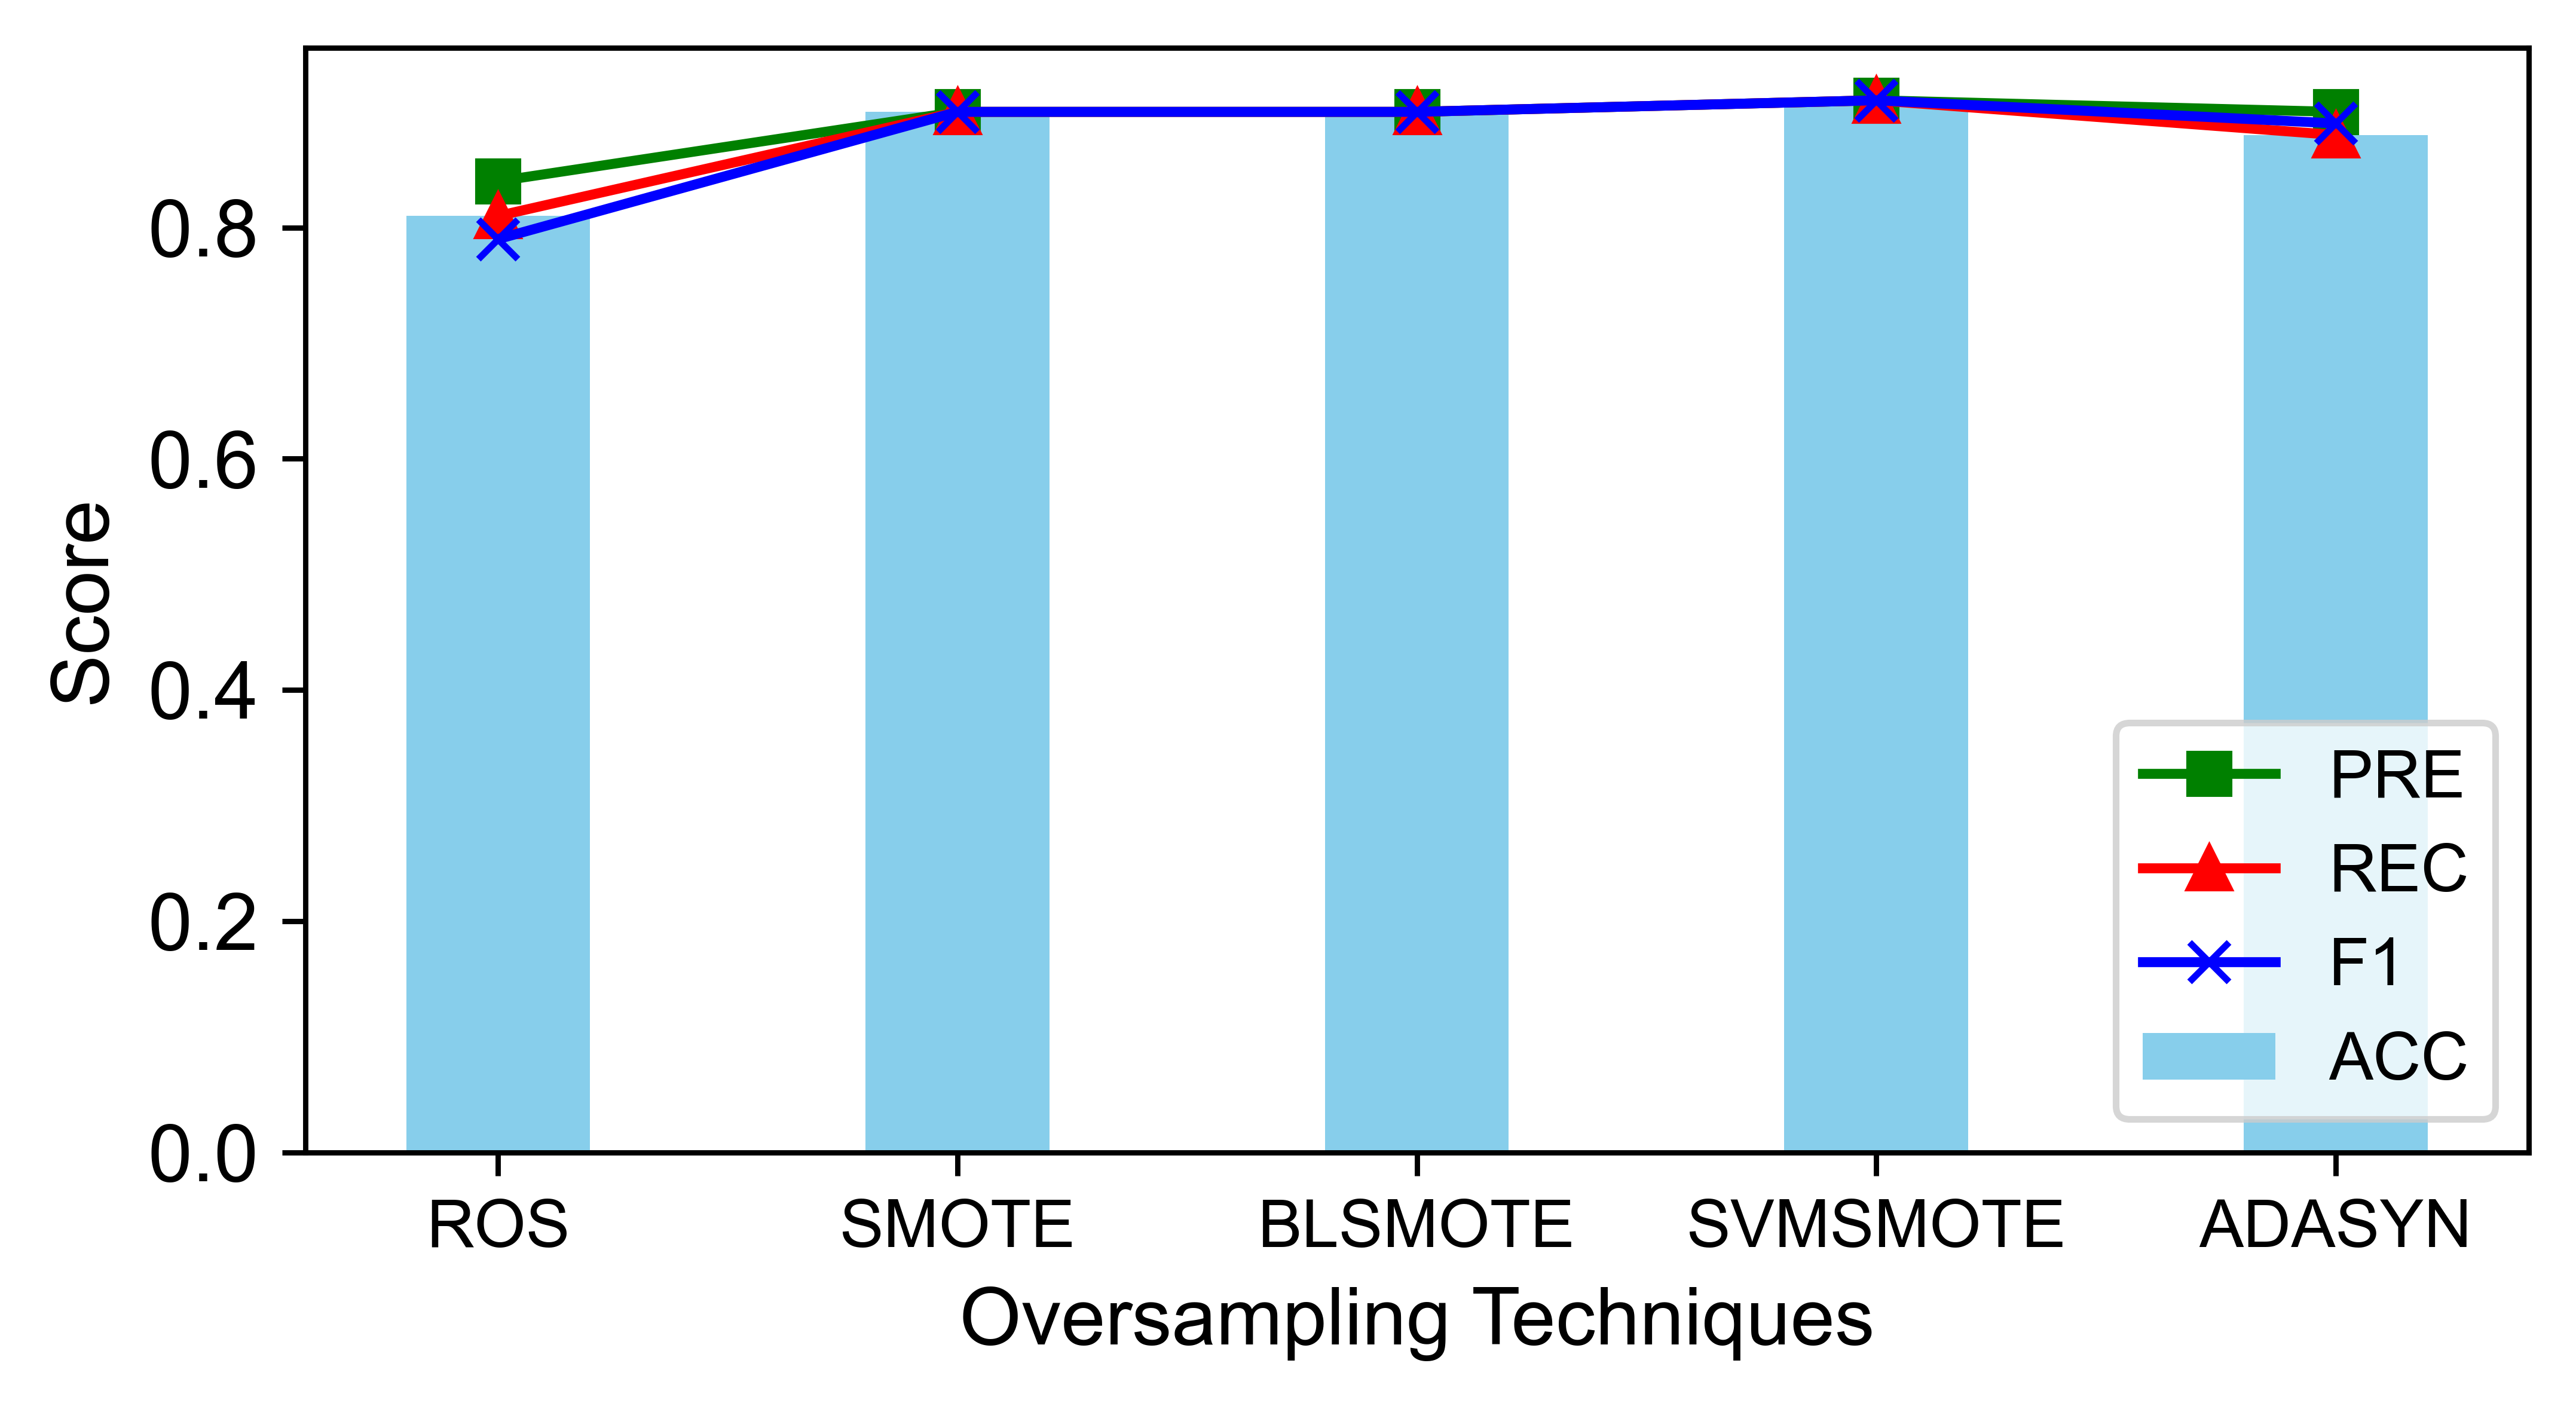

In [7]:
# Set font
plt.rcParams['font.family'] = 'Arial'

# Plotting the metrics
plt.figure(figsize=(6, 3), dpi=800)

# Get oversampler names
Oversampler_names = results_df['Oversampler'].tolist()

# Define dictionaries for each metric
accuracy_dict = dict(zip(Oversampler_names, results_df['Accuracy']))
precision_dict = dict(zip(Oversampler_names, results_df['Precision']))
recall_dict = dict(zip(Oversampler_names, results_df['Recall']))
f1_dict = dict(zip(Oversampler_names, results_df['F1-score']))

# Plot Accuracy (See here)

#plt.plot(Oversampler_names, [accuracy_dict[name] for name in Oversampler_names], label='Accuracy', marker='o', color=colors[0])
plt.bar(Oversampler_names, [accuracy_dict[name] for name in Oversampler_names], label='ACC', color='skyblue', width=0.4)

# Plot Precision
plt.plot(Oversampler_names, [precision_dict[name] for name in Oversampler_names], label='PRE', marker='s', color='green')

# Plot Recall
plt.plot(Oversampler_names, [recall_dict[name] for name in Oversampler_names], label='REC', marker='^', color= 'red')

# Plot F1-Score
plt.plot(Oversampler_names, [f1_dict[name] for name in Oversampler_names], label='F1', marker='x', color='blue')

# Adding labels and legend with customized font size
plt.xlabel('Oversampling Techniques', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=12)
plt.legend(loc= 'lower right', fontsize=10)
plt.grid(False)

# Show plot
plt.show()

## Selection of Optimized Oversampling Method
Five oversampling techniques consisting

-Random over-sampler (ROS)

-Synthetic minority over-sampling technique (SMOTE)

-Borderline SMOTE (BLSMOTE)

-Support vector technique SMOTE (SVMSMOTE)

-Adaptive synthetic sampling (ADASYN)

## The SMOTE technique shows better performance of evaluation metrics in comparison with other oversampling techniques.